# Bluestock Mutual Fund Capstone - Day 3 EDA Analysis

This notebook covers the exploratory data analysis for NAV, AUM, SIP, investor behaviour, folio growth, portfolio allocation and benchmark trends. The focus is on practical business observations rather than only technical charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

sns.set_theme(style="whitegrid")
RAW = Path("../data/raw")
CHART_DIR = Path("../reports/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


In [2]:
fund_master = pd.read_csv(RAW / "01_fund_master.csv")
nav_history = pd.read_csv(RAW / "02_nav_history.csv", parse_dates=["date"])
aum = pd.read_csv(RAW / "03_aum_by_fund_house.csv", parse_dates=["date"])
sip = pd.read_csv(RAW / "04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv(RAW / "05_category_inflows.csv")
folios = pd.read_csv(RAW / "06_industry_folio_count.csv")
scheme_perf = pd.read_csv(RAW / "07_scheme_performance.csv")
transactions = pd.read_csv(RAW / "08_investor_transactions.csv", parse_dates=["transaction_date"])
holdings = pd.read_csv(RAW / "09_portfolio_holdings.csv")
benchmark = pd.read_csv(RAW / "10_benchmark_indices.csv", parse_dates=["date"])

## 1. NAV trend analysis
Chart 1 uses Plotly for daily NAV trends across all 40 schemes. The 2023 phase is marked as a broad bull-run period, while 2024 is marked for correction/volatility observations.

In [3]:
nav_plot = nav_history.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code", how="left")
fig = px.line(nav_plot, x="date", y="nav", color="scheme_name", title="Daily NAV Trend for 40 Schemes (2022-2026)")
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", annotation_text="2023 bull run", fillcolor="green", opacity=0.12, line_width=0)
fig.add_vrect(x0="2024-04-01", x1="2024-06-30", annotation_text="2024 correction", fillcolor="red", opacity=0.12, line_width=0)
fig.show()

Static export used in the final report: `reports/charts/01_nav_trend_all_schemes.png`.

## 2. AUM growth by AMC

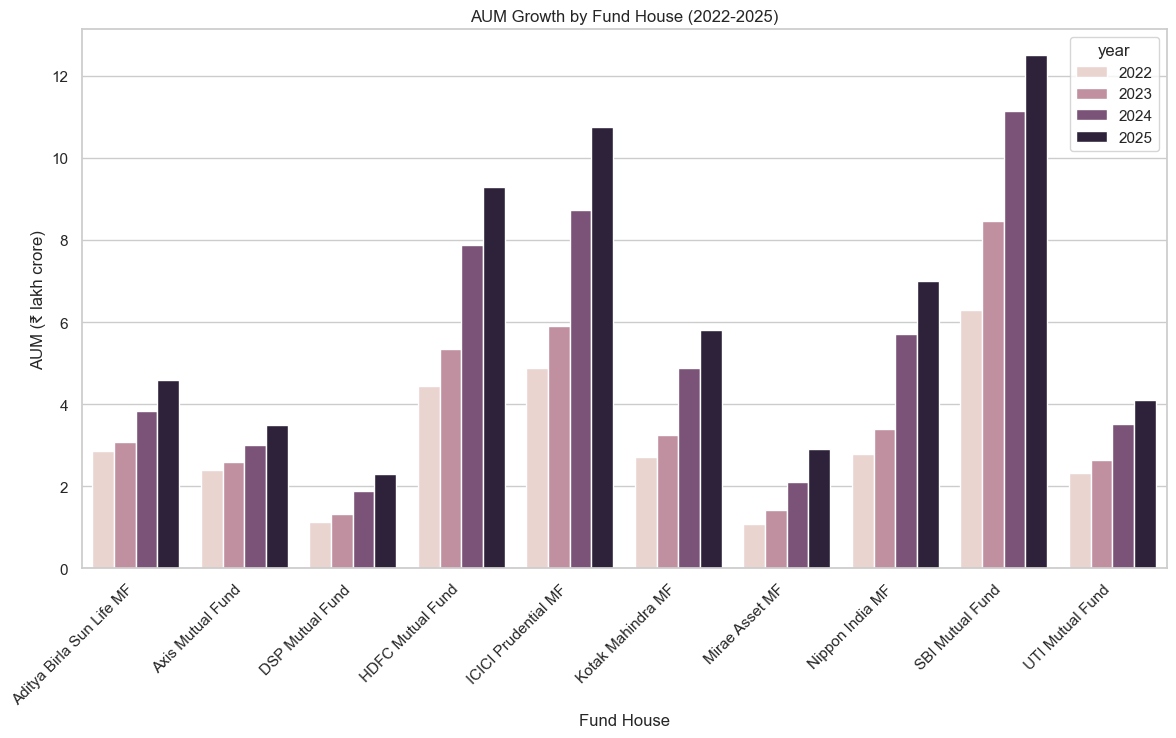

In [4]:
aum_yearly = aum.copy()
aum_yearly["year"] = aum_yearly["date"].dt.year
aum_yearly = aum_yearly.groupby(["year", "fund_house"])["aum_lakh_crore"].last().reset_index()
plt.figure(figsize=(14,7))
sns.barplot(data=aum_yearly, x="fund_house", y="aum_lakh_crore", hue="year")
plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ lakh crore)")
plt.xticks(rotation=45, ha="right")
plt.show()

## 3. SIP inflow time series

In [5]:
sip["month_dt"] = pd.to_datetime(sip["month"] + "-01")
fig = px.line(sip, x="month_dt", y="sip_inflow_crore", markers=True, title="Monthly SIP Inflow Trend")
fig.add_annotation(x="2025-12-01", y=31002, text="₹31,002 Cr all-time high", showarrow=True, arrowhead=2)
fig.show()

## 4. Category inflow heatmap

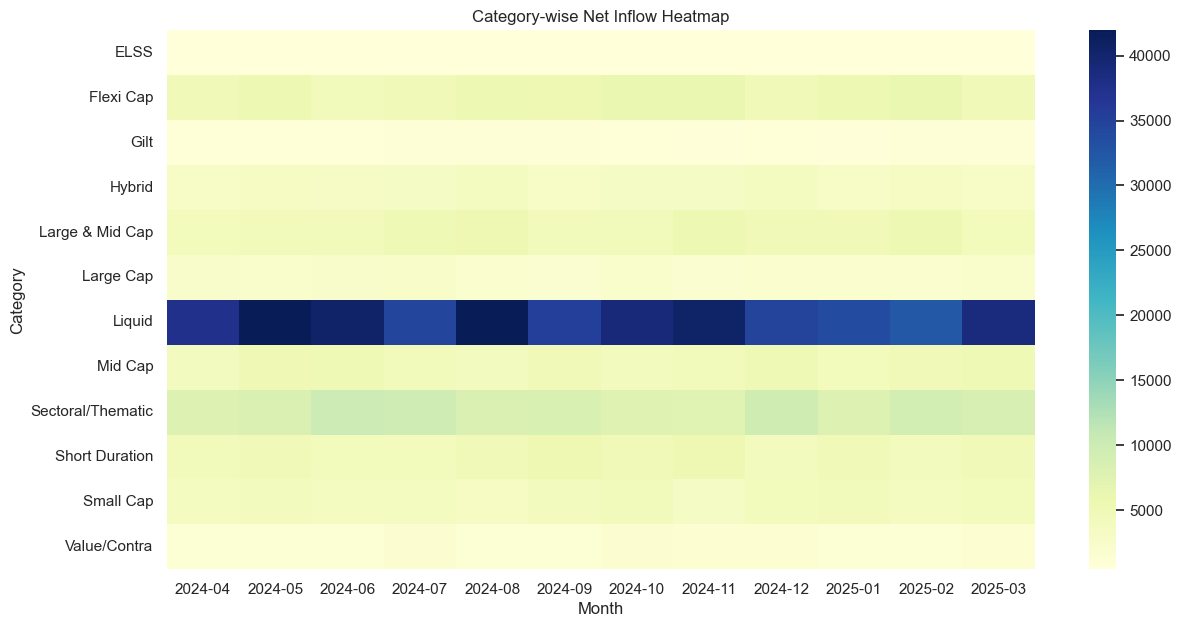

In [6]:
category_heatmap = category_inflows.pivot_table(index="category", columns="month", values="net_inflow_crore", aggfunc="sum")
plt.figure(figsize=(14,7))
sns.heatmap(category_heatmap, cmap="YlGnBu")
plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.show()

## 5. Investor demographics

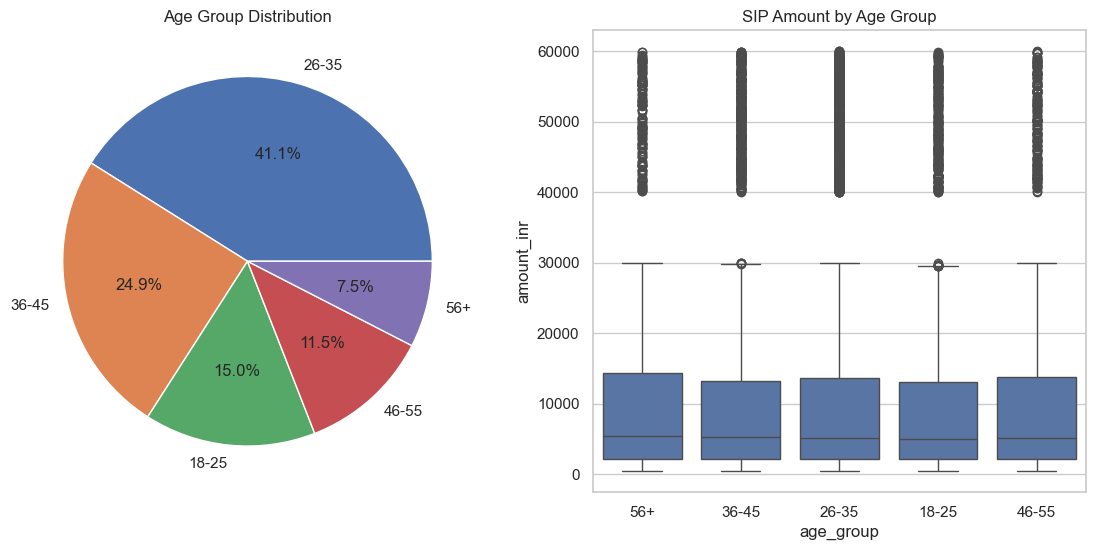

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
transactions["age_group"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[0])
axes[0].set_title("Age Group Distribution")
axes[0].set_ylabel("")
sns.boxplot(data=transactions[transactions["transaction_type"].str.upper()=="SIP"], x="age_group", y="amount_inr", ax=axes[1])
axes[1].set_title("SIP Amount by Age Group")
plt.show()

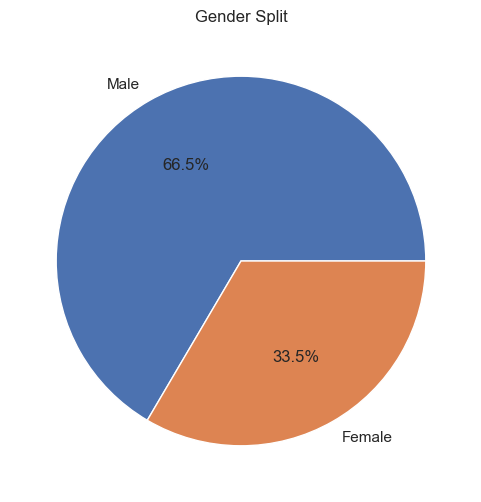

In [8]:
transactions["gender"].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6,6), title="Gender Split")
plt.ylabel("")
plt.show()

## 6. Geographic distribution

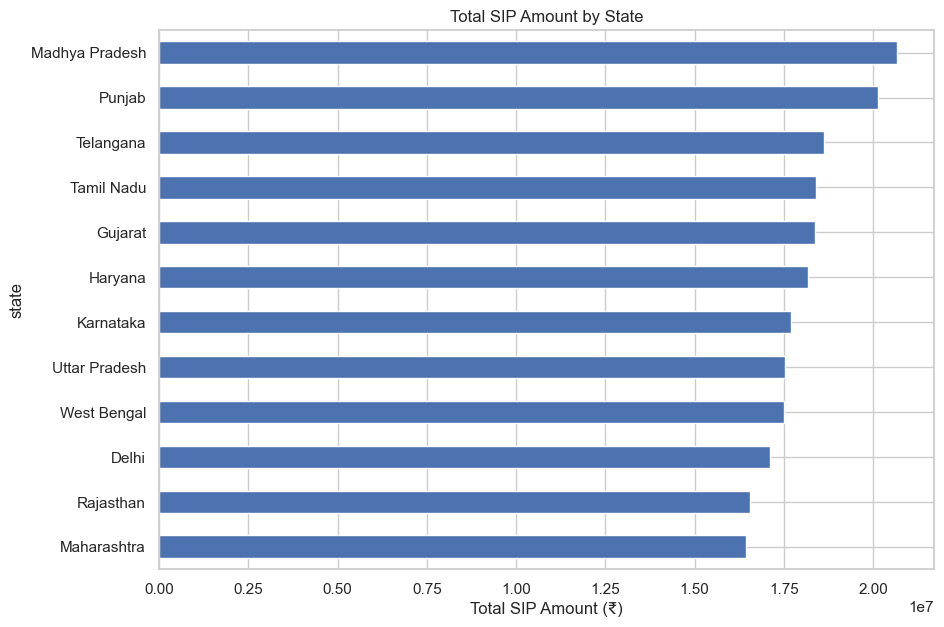

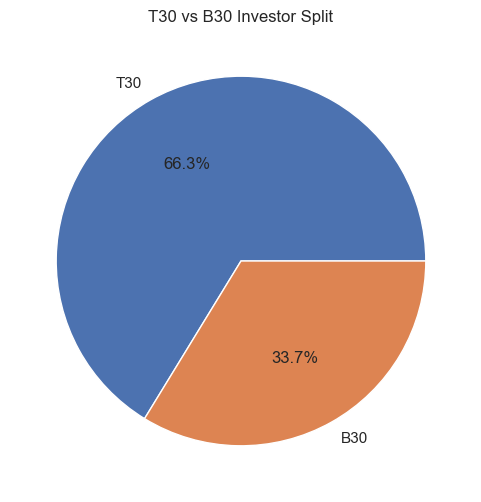

In [9]:
sip_transactions = transactions[transactions["transaction_type"].str.upper()=="SIP"]
state_sip = sip_transactions.groupby("state")["amount_inr"].sum().sort_values()
state_sip.plot.barh(figsize=(10,7), title="Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.show()

transactions["city_tier"].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6,6), title="T30 vs B30 Investor Split")
plt.ylabel("")
plt.show()

## 7. Folio count growth

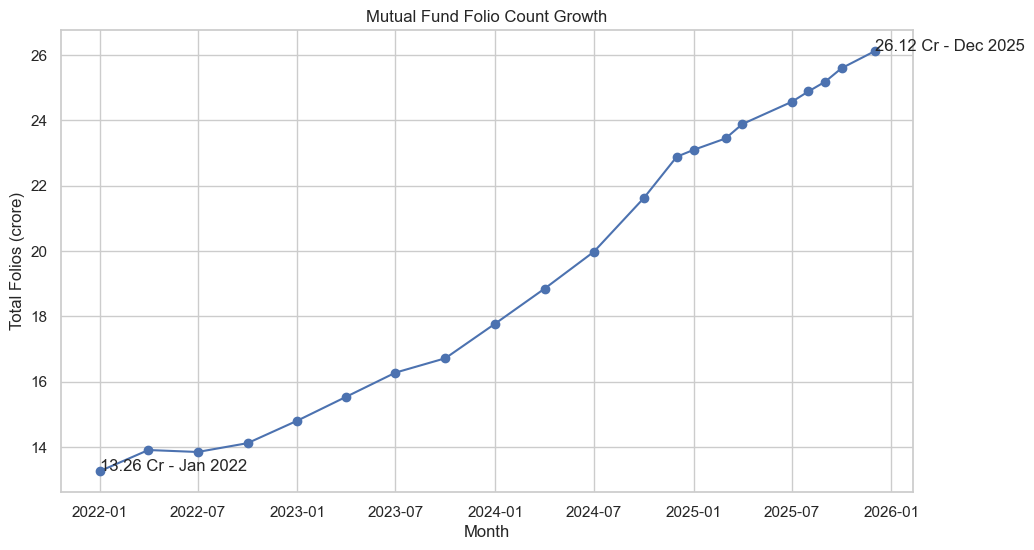

In [ ]:
folios["month_dt"] = pd.to_datetime(folios["month"] + "-01")
plt.figure(figsize=(11,6))
plt.plot(folios["month_dt"], folios["total_folios_crore"], marker="o")
plt.title("Mutual Fund Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (crore)")
plt.annotate("13.26 Cr - Jan 2022", xy=(folios["month_dt"].iloc[0], folios["total_folios_crore"].iloc[0]))
plt.annotate("26.12 Cr - Dec 2025", xy=(folios["month_dt"].iloc[-1], folios["total_folios_crore"].iloc[-1]))
plt.show()

## 8. NAV return correlation matrix

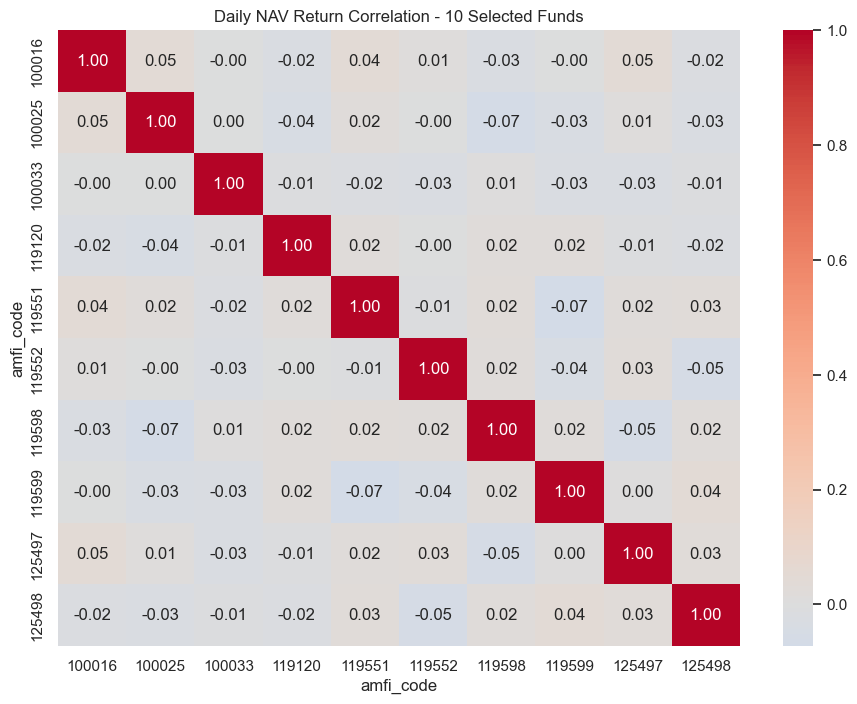

In [ ]:
selected_codes = fund_master["amfi_code"].head(10).tolist()
returns = nav_history[nav_history["amfi_code"].isin(selected_codes)].sort_values(["amfi_code", "date"])
returns["daily_return"] = returns.groupby("amfi_code")["nav"].pct_change()
returns_pivot = returns.pivot(index="date", columns="amfi_code", values="daily_return")
plt.figure(figsize=(11,8))
sns.heatmap(returns_pivot.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Daily NAV Return Correlation - 10 Selected Funds")
plt.show()

## 9. Sector allocation donut

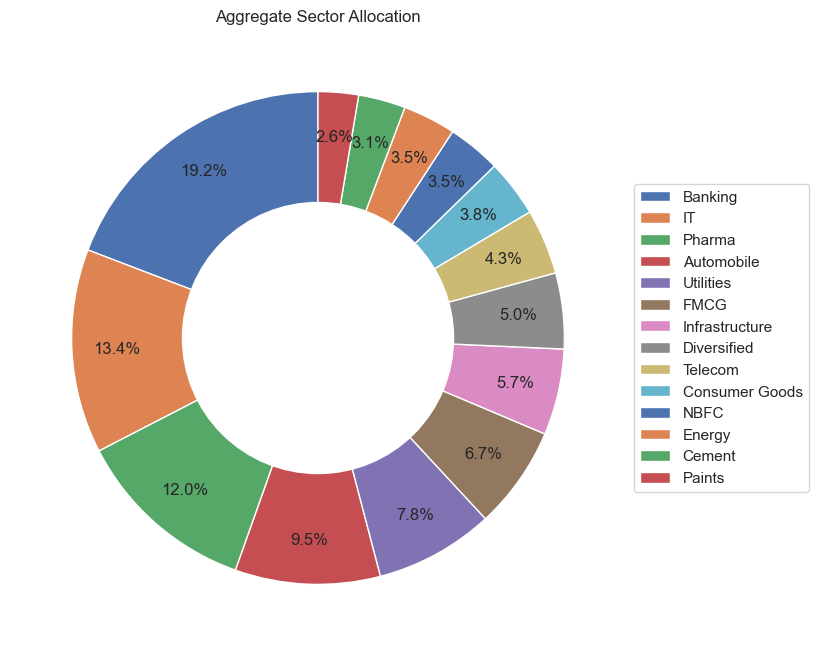

In [ ]:
sector_allocation = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,8))
wedges, texts, autotexts = plt.pie(sector_allocation, autopct="%1.1f%%", startangle=90, pctdistance=0.82)
centre_circle = plt.Circle((0,0),0.55,fc="white")
plt.gca().add_artist(centre_circle)
plt.title("Aggregate Sector Allocation")
plt.legend(wedges, sector_allocation.index, loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

## 10 Key EDA Findings

1. **Chart 1:** NAV values across the 40 schemes generally moved upward during 2023, supporting the broad bull-run observation.
2. **Chart 1:** Some schemes showed visible volatility during 2024, which aligns with the correction/market fluctuation period marked in the NAV chart.
3. **Chart 2:** SBI Mutual Fund remained the largest AMC by AUM in the dataset, ending near the ₹12.5 lakh crore level.
4. **Chart 3:** SIP inflows show a consistent upward trend from 2022 to 2025, with the highest point recorded in December 2025.
5. **Chart 4:** Equity-oriented categories contributed strongly to monthly net inflows compared with relatively defensive categories.
6. **Chart 5 and 6:** Investor participation is distributed across all age groups, but SIP ticket sizes vary noticeably by age bracket.
7. **Chart 7:** The investor gender split is reasonably balanced, so demographic analysis should not depend only on one gender segment.
8. **Chart 8:** SIP contribution is concentrated in a few major states, indicating geography can influence investor acquisition strategy.
9. **Chart 9:** Both T30 and B30 city groups are represented, making city-tier segmentation useful for distributor-level insights.
10. **Chart 12:** Banking and financial-sector exposure appears important in aggregate portfolio holdings, so sector concentration should be monitored in later risk analysis.